## Interpretability 
### Feature importance bar

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import torch
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from datetime import datetime
from tqdm import tqdm
from torch.optim import LBFGS
import torch.nn as nn

################################
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

/home/defuser/miniconda3/envs/KAN/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [2]:
class NaiveFourierKANLayer(nn.Module):
    def __init__(self, inputdim, outdim, gridsize, addbias=True, smooth_initialization=False):
        super(NaiveFourierKANLayer, self).__init__()
        self.gridsize = gridsize
        self.addbias = addbias
        self.inputdim = inputdim
        self.outdim = outdim

        grid_norm_factor = (torch.arange(gridsize) + 1) ** 2 if smooth_initialization else np.sqrt(gridsize)

        self.fouriercoeffs = nn.Parameter(torch.randn(2, outdim, inputdim, gridsize) /
                                          (np.sqrt(inputdim) * grid_norm_factor))
        if self.addbias:
            self.bias = nn.Parameter(torch.zeros(1, outdim))

    def forward(self, x):
        xshp = x.shape
        outshape = xshp[0:-1] + (self.outdim,)
        x = torch.reshape(x, (-1, self.inputdim))
        k = torch.reshape(torch.arange(1, self.gridsize + 1, device=x.device), (1, 1, 1, self.gridsize))
        xrshp = torch.reshape(x, (x.shape[0], 1, x.shape[1], 1))
        c = torch.cos(k * xrshp)
        s = torch.sin(k * xrshp)
        y = torch.sum(c * self.fouriercoeffs[0:1], (-2, -1))
        y += torch.sum(s * self.fouriercoeffs[1:2], (-2, -1))
        if self.addbias:
            y += self.bias
        y = torch.reshape(y, outshape)
        return y
################################
class fKAN(nn.Module):
    def __init__(self, layers, gridsizes):
        super(fKAN, self).__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers) - 2):
            self.layers.append(NaiveFourierKANLayer(layers[i], layers[i + 1], gridsize=gridsizes[i]))
        self.layers.append(nn.Linear(layers[len(layers) - 2], layers[len(layers) - 1]))

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

def fit(model, dataset, steps=100, loss_fn=None, lr=1., batch=-1):
    pbar = tqdm(range(steps), desc='description', ncols=100)
    optimizer = LBFGS(model.parameters(), lr=lr, history_size=10, line_search_fn="strong_wolfe", tolerance_grad=1e-32, tolerance_change=1e-32)

    results = {}
    results['train_loss'] = []
    results['test_loss'] = []

    if batch == -1 or batch > dataset['train_input'].shape[0]:
        batch_size = dataset['train_input'].shape[0]
        batch_size_test = dataset['test_input'].shape[0]
    else:
        batch_size = batch
        batch_size_test = batch

    global train_loss

    def closure():
        global train_loss
        optimizer.zero_grad()
        pred = model.forward(dataset['train_input'][train_id])
        train_loss = loss_fn(pred, dataset['train_label'][train_id])
        objective = train_loss
        objective.backward()
        return objective

    for _ in pbar:

        train_id = np.random.choice(dataset['train_input'].shape[0], batch_size, replace=False)
        test_id = np.random.choice(dataset['test_input'].shape[0], batch_size_test, replace=False)

        optimizer.step(closure)

        test_loss = loss_fn(model.forward(dataset['test_input'][test_id]), dataset['test_label'][test_id])

        results['train_loss'].append(torch.sqrt(train_loss).cpu().detach().numpy())
        results['test_loss'].append(torch.sqrt(test_loss).cpu().detach().numpy())
        pbar.set_description("| train_loss: %.2e | test_loss: %.2e " % (torch.sqrt(train_loss).cpu().detach().numpy(), torch.sqrt(test_loss).cpu().detach().numpy()))

    return results

def objective(trial):
    depth = trial.suggest_int("depth", 1, MAX_DEPTH)
    width = [trial.suggest_int(f"neurons_layer_{i}", 5, MAX_NEURONS, step=5) for i in range(depth)]
    grids = [trial.suggest_int(f"grids_{i}", 1, MAX_GRID) for i in range(depth)]
    width = [input_shape] + width + [output_shape]
    model = fKAN(width, grids).to(device)

    history = fit(model, dataset, steps=EPOCHS, loss_fn=torch.nn.CrossEntropyLoss())

    y_score = model(X_valid).cpu()
    y_pred = (y_score > 0.5).int()

    return f1_score(y_valid.cpu(), y_pred, average="macro")

In [3]:
best_params_CA = {
    "depth": 2,
    "grids_0": 8,
    "grids_1": 3,
    "neurons_layer_0": 30,
    "neurons_layer_1": 35
}

In [4]:
EPOCHS = 100


## Fix your dataset here ###
DATA = 'CA'
data = pd.read_csv('CA.csv')
############################


data.fillna(0, inplace=True)
y = data["target_label"].values
data.drop("target_label", axis=1, inplace=True)
X = data.values.astype(np.float32)

if y.dtype == "object":
    label_encoder = LabelEncoder()
    y = torch.tensor(label_encoder.fit_transform(y))
else:
    y = torch.tensor(y)


X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, stratify=y_train, test_size=0.1, random_state=42)

scaler = StandardScaler()
X_train = torch.tensor(scaler.fit_transform(X_train)).to(device)
X_valid = torch.tensor(scaler.transform(X_valid)).to(device)
X_test = torch.tensor(scaler.transform(X_test)).to(device)

y_train = torch.nn.functional.one_hot(y_train.long(), num_classes=2).to(device).float()
y_valid = torch.nn.functional.one_hot(y_valid.long(), num_classes=2).to(device).float()
y_test = torch.nn.functional.one_hot(y_test.long(), num_classes=2).to(device).float()

input_shape = X_train.shape[1]
output_shape = y_train.shape[1]

dataset = {
"train_input": X_train,
"train_label": y_train,
"test_input": X_valid,
"test_label": y_valid,
}

best_params = best_params_CA
print('best_params:', best_params)

depth = best_params["depth"]
width = [best_params[f"neurons_layer_{i}"] for i in range(depth)]
width = [input_shape] + width + [output_shape]
grids = [best_params[f"grids_{i}"] for i in range(depth)]

model = fKAN(width, grids).to(device)
history = fit(model, dataset, steps=EPOCHS, loss_fn=torch.nn.CrossEntropyLoss())

y_score = model(X_test).cpu()
y_pred = (y_score > 0.5).int()

print(classification_report(y_test.cpu(), y_pred, target_names=label_encoder.classes_))
print("ROC-AUC: %.4f" % roc_auc_score(y_test.cpu(), y_pred))

best_params: {'depth': 2, 'grids_0': 8, 'grids_1': 3, 'neurons_layer_0': 30, 'neurons_layer_1': 35}


| train_loss: -0.00e+00 | test_loss: 1.49e+00 : 100%|█████████████| 100/100 [00:03<00:00, 29.55it/s]


              precision    recall  f1-score   support

           +       0.84      0.77      0.80        77
           -       0.79      0.84      0.82        77

   micro avg       0.82      0.81      0.81       154
   macro avg       0.82      0.81      0.81       154
weighted avg       0.82      0.81      0.81       154
 samples avg       0.81      0.81      0.81       154

ROC-AUC: 0.8117


/home/defuser/miniconda3/envs/KAN/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Model

model

In [5]:
layerindex = 0

inputdim = model.layers[layerindex].inputdim 
outdim = model.layers[layerindex].outdim      
gridsize = model.layers[layerindex].gridsize 


cos_coeffs = model.layers[layerindex].fouriercoeffs[0].detach().cpu().numpy()  # Cosine coefficients
sin_coeffs = model.layers[layerindex].fouriercoeffs[1].detach().cpu().numpy()  # Sine coefficients

coefficient_matrix = np.zeros((inputdim, 2 * outdim * gridsize))

for i in range(inputdim):

    cos_flat = cos_coeffs[:, i, :].flatten()  
    sin_flat = sin_coeffs[:, i, :].flatten()  
    coefficient_matrix[i] = np.concatenate([cos_flat, sin_flat])

In [6]:
coefficient_matrix.shape

(49, 480)

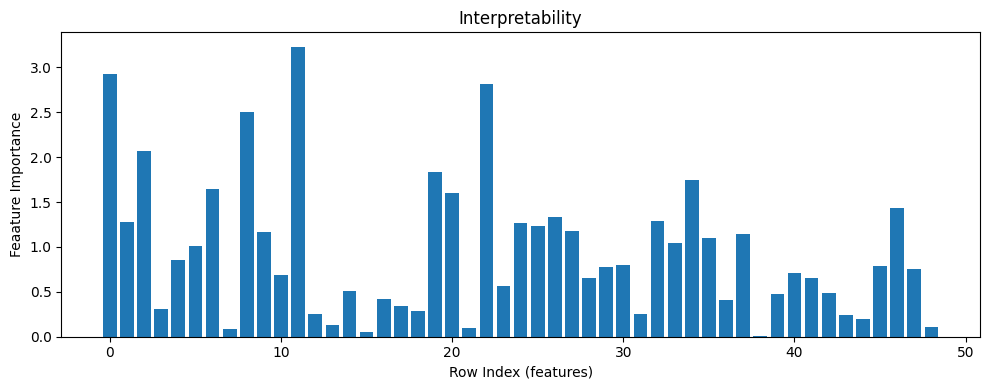

In [7]:
summed_vector = coefficient_matrix.sum(axis=1)
# print(summed_vector)


plt.figure(figsize=(10, 4))
plt.bar(np.arange(len(summed_vector)), abs(summed_vector))
plt.xlabel("Row Index (features)")
plt.ylabel("Feaature Importance")
plt.title("Interpretability")
plt.tight_layout()
plt.show()
